<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed:


In [2]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print('All libraries installed.')

All libraries installed.


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:

In [8]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv"

df = pd.read_csv(file_path)

df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [14]:
data = df['CompTotal'].dropna()
print('There are', data.value_counts().shape[0] , 'different values in the CompTotal column.')

There are 1509 different values in the CompTotal column.


In [15]:
"""
Because we have many different values we will group them in 4 sections.
Each section will be a quantile.
We will exclude outliers.
"""

'\nBecause we have many different values we will group them in 4 sections.\nEach section will be a quantile.\nWe will exclude outliers.\n'

In [16]:
# Quartiles
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

# IQR
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)

Q1: 25000.0
Q3: 120000.0
IQR: 95000.0


In [17]:
# In this case we will accept every compensation value up to 535000. If we wanted to keep higher compensations in the analysis we would simply modify the upper 

In [18]:
# Define bounds
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: 0
Upper Bound: 262500.0


In [19]:
outliers = data[(data < lower_bound) | (data > upper_bound)]

In [20]:
print('Number of outliers:', len(outliers))

Number of outliers: 1120


In [21]:
# We will drop the outliers from our data, so that they are excluded from the analysis
clean_data = data[(data >= lower_bound) & (data <= upper_bound)]

In [22]:
print("Original size:", len(data))
print("Cleaned size:", len(clean_data))
print("Removed outliers:", len(data) - len(clean_data))
print("After handling outliers, the new number of different values in the CompTotal is:", clean_data.value_counts().shape[0])

Original size: 10589
Cleaned size: 9469
Removed outliers: 1120
After handling outliers, the new number of different values in the CompTotal is: 1163


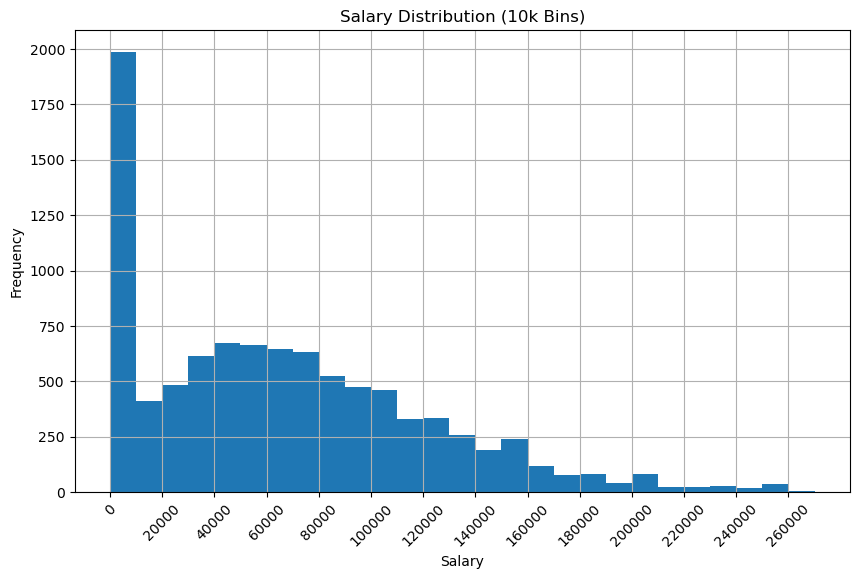

In [23]:
# Histogram
bin_width = 10000
bins = np.arange(0, 280000, bin_width)

plt.figure(figsize=(10, 6))
plt.hist(clean_data, bins=bins)

plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution (10k Bins)')
plt.xticks(bins[::2], rotation=45)
plt.grid(True)

plt.show()

In [14]:
# As we can see, the histogram above is left skewed. Most survey participants have total compensation between 40000 and 80000.

**Count Plots**

Plot a count plot of Age.


In [24]:
df_age = df['Age'].dropna()

C:\Users\marko\AppData\Local\Temp\ipykernel_16752\1129407024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[['Age']], y='Age', palette="viridis")


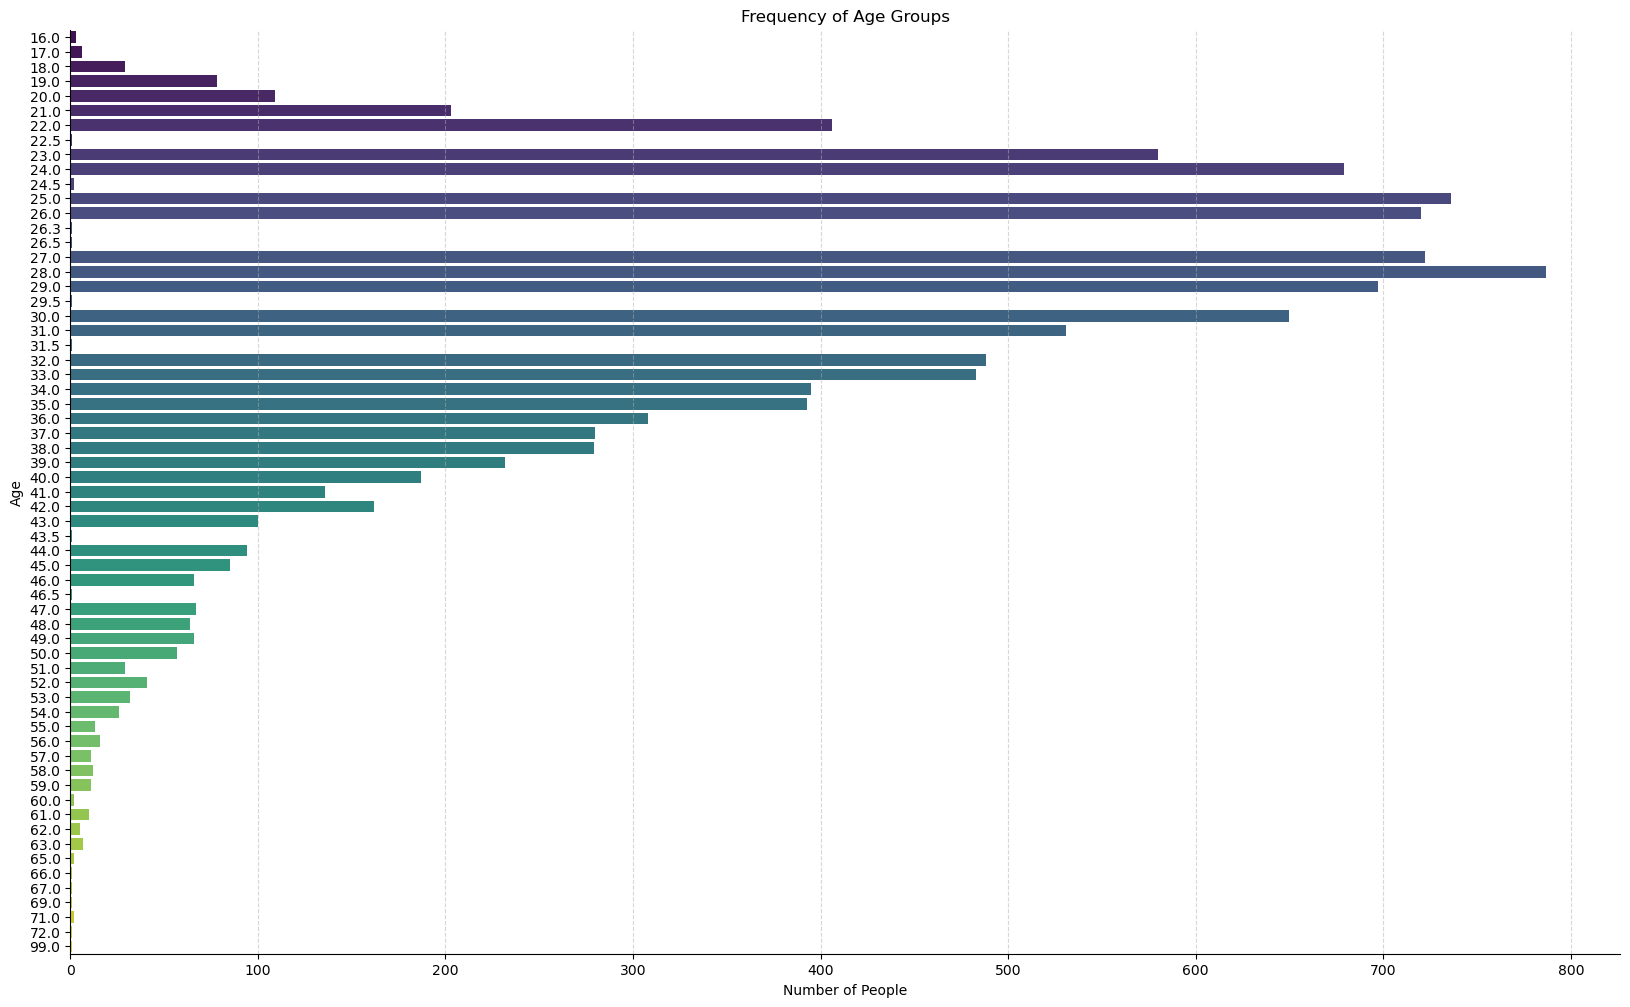

In [25]:
plt.figure(figsize=(20, 12))
sns.countplot(data=df[['Age']], y='Age', palette="viridis")
# Remove top/right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Frequency of Age Groups")
plt.xlabel("Number of People")
# Add subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkWeekHrs.


In [26]:
scatter_data = df[['Age','WorkWeekHrs']]
scatter_data = scatter_data.dropna()

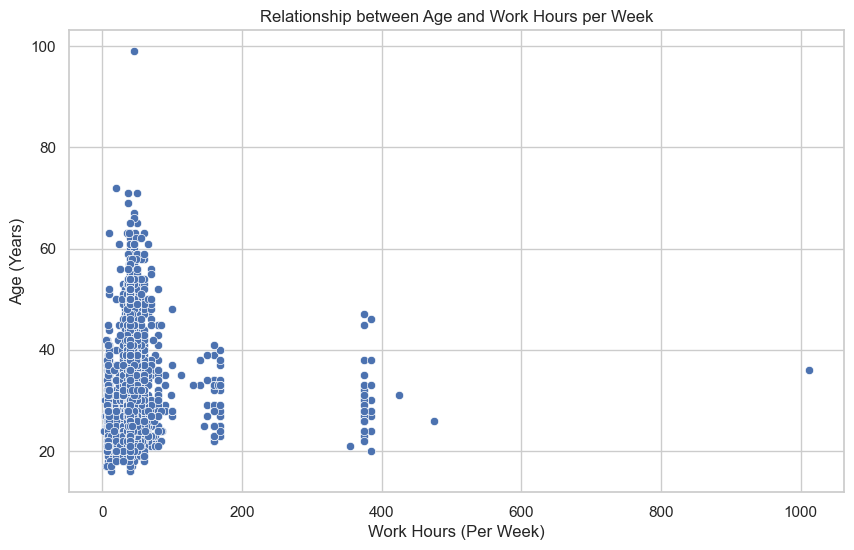

In [40]:
sns.set_theme(style="whitegrid")

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x='WorkWeekHrs', y='Age')

# Add titles and labels for clarity
plt.title('Relationship between Age and Work Hours per Week')
plt.xlabel('Work Hours (Per Week)')
plt.ylabel('Age (Years)')

# Display the plot
plt.show()

**Bubble Plots**

Create a bubble plot of WorkWeekHrs and CodeRevHrs, use Age column as bubble size

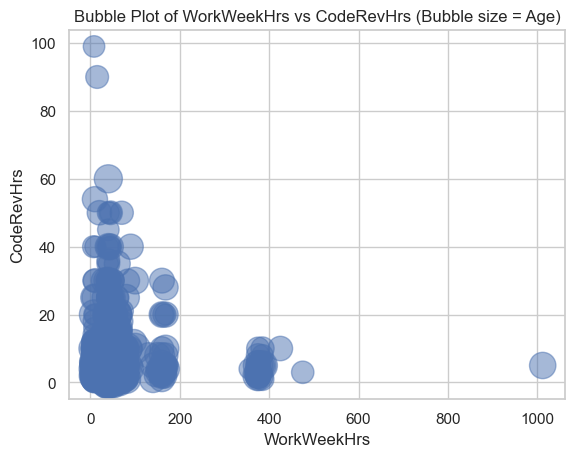

In [28]:
x = df['WorkWeekHrs']
y = df['CodeRevHrs']
sizes = df['Age'] * 10

plt.figure()
plt.scatter(x, y, s=sizes, alpha=0.5)

plt.xlabel('WorkWeekHrs')
plt.ylabel('CodeRevHrs')
plt.title('Bubble Plot of WorkWeekHrs vs CodeRevHrs (Bubble size = Age)')

plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [ ]:
# We have previously proved that based on the IQR every Compensation above 262500.0 is an outlier

In [35]:
df_filtered = df[(df['CompTotal'] >= 0) & (df['CompTotal'] <= 262500)]

In [36]:
df_filtered = df_filtered[(df_filtered['Age'] >= 45) & (df_filtered['Age'] <= 60)]

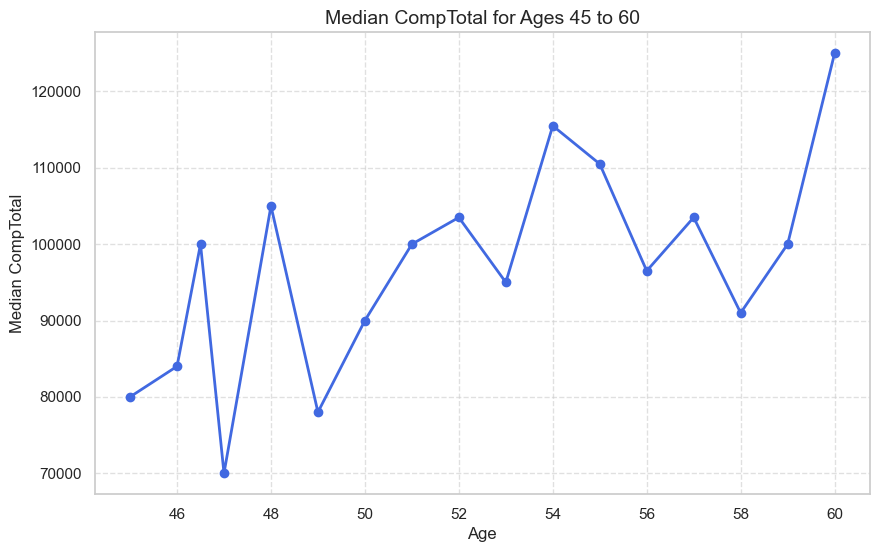

In [38]:
median_comp = df_filtered.groupby('Age')['CompTotal'].median()

# 3. Plot the results
plt.figure(figsize=(10, 6))
median_comp.plot(kind='line', marker='o', color='royalblue', linewidth=2)

# Adding labels and title
plt.title('Median CompTotal for Ages 45 to 60', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Median CompTotal', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


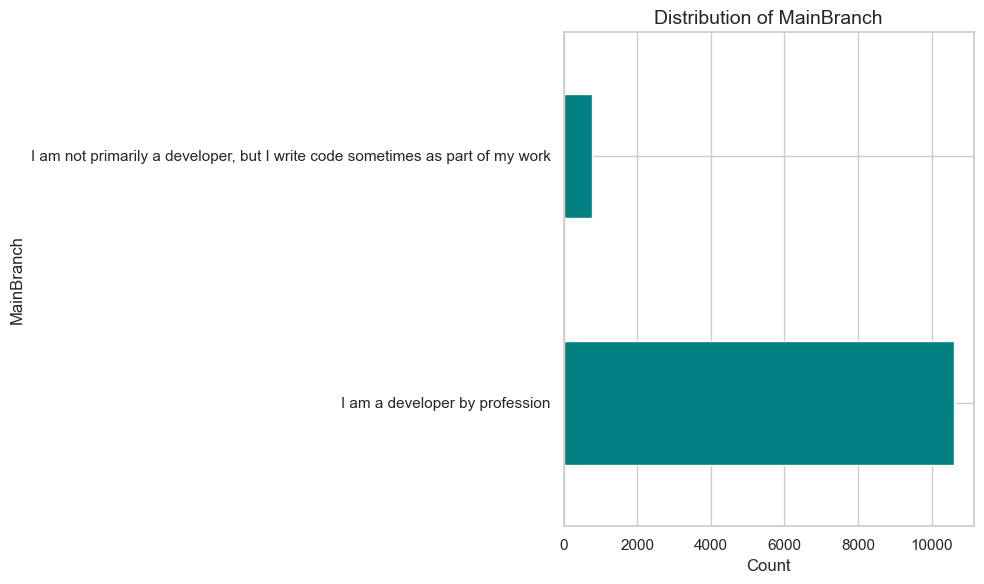

In [39]:
branch_counts = df['MainBranch'].value_counts()

# 2. Plot as a horizontal bar chart
plt.figure(figsize=(10, 6))
branch_counts.plot(kind='barh', color='teal')

# 3. Add labels and title
plt.title('Distribution of MainBranch', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('MainBranch', fontsize=12)

# 4. Use tight_layout to ensure long category names aren't cut off
plt.tight_layout()

# 5. Display the plot
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkWeekHours, and CodeRevHrs.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
